# Kang IFNb CD14 monocyte response analysis

This notebook tests IFNb responsiveness as a donor-adjusted response gradient within CD14+ monocytes. The main response labels are created only after subsetting to CD14+ monocytes, so `low` and `high` refer to top/bottom stimulated CD14 cells within each donor, not to global stimulated PBMC quantiles.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

import spVIPESmulti

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

sc.settings.set_figure_params(dpi=100, frameon=False)

NOTEBOOK_DIR = Path("docs/notebooks") if Path("docs/notebooks").exists() else Path(".")
DATA_CANDIDATES = [
    NOTEBOOK_DIR / "data" / "kang_2018.h5ad",
    Path("data") / "kang_2018.h5ad",
]

torch.cuda.is_available()


True

In [2]:
IFN_BETA_RESPONSE_GENES = [
    "IFNAR1", "IFNAR2", "IFNB1", "STAT1", "STAT2", "TYK2", "JAK1",
    "IRF9", "IRF1", "IRF7", "IRF3", "OAS1", "OAS2", "OAS3", "MX1",
    "MX2", "ISG15", "RSAD2", "IFI27", "IFI44", "IFI44L", "IFIT1",
    "IFIT2", "IFIT3", "IFIT5", "IFITM1", "IFITM2", "IFITM3",
    "IFI6", "IFIH1", "IFIT1B", "IFITM10", "OASL", "BST2", "IFITM5",
]


def load_kang_2018():
    for candidate in DATA_CANDIDATES:
        if candidate.exists() and candidate.stat().st_size > 0:
            print(f"Loading Kang data from {candidate}")
            return sc.read_h5ad(candidate)
    import pertpy as pt
    print("Local Kang h5ad not found; falling back to pertpy.data.kang_2018().")
    return pt.data.kang_2018()


def present_genes(adata, genes):
    return [gene for gene in genes if gene in adata.var_names]


def score_ifn_response(adata, score_name="ISG_score"):
    genes = present_genes(adata, IFN_BETA_RESPONSE_GENES)
    missing = sorted(set(IFN_BETA_RESPONSE_GENES) - set(genes))
    print(f"IFN-response genes present: {len(genes)} / {len(IFN_BETA_RESPONSE_GENES)}")
    if missing:
        print("Missing genes:", missing)
    if len(genes) < 5:
        raise ValueError("Too few IFN-response genes are present to compute a stable score.")
    sc.tl.score_genes(adata, gene_list=genes, score_name=score_name, use_raw=False)
    return genes


def add_donor_adjusted_response(
    adata,
    score_key="ISG_score",
    out_key="ISG_z_by_donor",
    strata=("label", "replicate"),
):
    def _zscore(values):
        values = values.astype(float)
        std = values.std(ddof=0)
        if not np.isfinite(std) or std == 0:
            return pd.Series(np.zeros(values.shape[0]), index=values.index)
        return (values - values.mean()) / std

    adata.obs[out_key] = (
        adata.obs.groupby(list(strata), observed=True)[score_key]
        .transform(_zscore)
        .astype(float)
    )


def add_cd14_response_extremes(
    adata,
    score_key="ISG_z_by_donor",
    condition_key="label",
    stim_value="stim",
    donor_key="replicate",
    out_key="ifnb_response_extreme",
    lower_q=0.2,
    upper_q=0.8,
):
    labels = pd.Series("middle", index=adata.obs_names, dtype="object")
    labels.loc[adata.obs[condition_key] != stim_value] = "ctrl"

    stim_obs = adata.obs[adata.obs[condition_key] == stim_value]
    for donor, idx in stim_obs.groupby(donor_key, observed=True).groups.items():
        scores = adata.obs.loc[idx, score_key].astype(float)
        low_cut = scores.quantile(lower_q)
        high_cut = scores.quantile(upper_q)
        labels.loc[scores.index[scores <= low_cut]] = "low"
        labels.loc[scores.index[scores >= high_cut]] = "high"

    adata.obs[out_key] = pd.Categorical(
        labels,
        categories=["ctrl", "low", "middle", "high"],
        ordered=True,
    )

    counts = pd.crosstab(
        adata.obs.loc[adata.obs[condition_key] == stim_value, donor_key],
        adata.obs.loc[adata.obs[condition_key] == stim_value, out_key],
    ).reindex(columns=["low", "middle", "high"], fill_value=0)
    if (counts[["low", "high"]] == 0).any().any():
        raise ValueError("Every stimulated donor must have nonzero low and high CD14 response cells.")
    return counts


def probe_balanced_accuracy(x, y, seed=SEED):
    y = np.asarray(y).astype(str)
    classes, counts = np.unique(y, return_counts=True)
    if classes.size < 2:
        return np.nan
    stratify = y if counts.min() >= 2 else None
    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.3,
        random_state=seed,
        stratify=stratify,
    )
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(x_train, y_train)
    return balanced_accuracy_score(y_test, clf.predict(x_test))


def _bh_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan, dtype=float)
    finite = np.isfinite(p_values)
    if finite.sum() == 0:
        return adjusted
    p = p_values[finite]
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)
    adj_ranked = ranked * m / np.arange(1, m + 1)
    adj_ranked = np.minimum.accumulate(adj_ranked[::-1])[::-1]
    adj_ranked = np.clip(adj_ranked, 0, 1)
    finite_idx = np.where(finite)[0]
    adjusted[finite_idx[order]] = adj_ranked
    return adjusted


def latent_response_summary(
    adata,
    obsm_key,
    score_key="ISG_z_by_donor",
    label_key="ifnb_response_extreme",
):
    x = np.asarray(adata.obsm[obsm_key])
    score = pd.to_numeric(adata.obs[score_key], errors="coerce").to_numpy()
    finite_score = np.isfinite(score)
    response_labels = adata.obs[label_key].astype(str).to_numpy()
    extreme = np.isin(response_labels, ["low", "high"])
    n_low = int((response_labels == "low").sum())
    n_high = int((response_labels == "high").sum())

    rows = []
    for dim_idx in range(x.shape[1]):
        dim = x[:, dim_idx]
        finite_dim = np.isfinite(dim)
        corr_mask = finite_score & finite_dim
        if corr_mask.sum() >= 3 and np.nanstd(dim[corr_mask]) > 0:
            rho, p_value = spearmanr(dim[corr_mask], score[corr_mask])
        else:
            rho, p_value = np.nan, np.nan

        auc = np.nan
        auc_abs = np.nan
        auc_mask = extreme & finite_dim
        if auc_mask.sum() >= 3:
            y = (response_labels[auc_mask] == "high").astype(int)
            if np.unique(y).size == 2 and np.nanstd(dim[auc_mask]) > 0:
                auc = roc_auc_score(y, dim[auc_mask])
                auc_abs = max(auc, 1.0 - auc)

        rows.append({
            "dim": dim_idx,
            "n_cells": int(corr_mask.sum()),
            "n_low": n_low,
            "n_high": n_high,
            "spearman_r": rho,
            "spearman_abs": abs(rho) if np.isfinite(rho) else np.nan,
            "spearman_p": p_value,
            "auc_high_vs_low": auc,
            "auc_directionless": auc_abs,
        })

    out = pd.DataFrame(rows)
    out["spearman_p_adj_bh"] = _bh_adjust(out["spearman_p"].to_numpy())
    return out.sort_values(["spearman_abs", "auc_directionless"], ascending=False).reset_index(drop=True)


def private_loadings_heatmap(model, group_idx, dims, n_top=8, ax=None):
    import seaborn as sns

    loadings = model.get_loadings()[(group_idx, "private")]
    cols = [f"Z_private_{dim_idx}" for dim_idx in dims]
    missing = [col for col in cols if col not in loadings.columns]
    if missing:
        raise KeyError(f"Missing private loading columns: {missing}")

    selected_genes = []
    for col in cols:
        top = loadings[col].abs().sort_values(ascending=False).head(n_top).index.tolist()
        for gene in top:
            if gene not in selected_genes:
                selected_genes.append(gene)

    plot_df = loadings.loc[selected_genes, cols].T
    if ax is None:
        _, ax = plt.subplots(figsize=(max(8, 0.45 * len(selected_genes)), max(3.5, 0.45 * len(cols))))
    sns.heatmap(plot_df, center=0, cmap="vlag", ax=ax, cbar_kws={"label": "loading"})
    ax.set_xlabel("Gene")
    ax.set_ylabel("Stim private dimension")
    ax.set_title("Top absolute private loadings for response-associated dimensions")
    return ax


## Load and score broad response

This stage scores IFN response on the full dataset only for diagnostics. The response classes used for model evaluation are created later, after subsetting to CD14+ monocytes.


In [3]:
adata = load_kang_2018()
adata = adata[adata.obs["cell_type"] != "Megakaryocytes"].copy()

print(f"Shape      : {adata.shape}")
print(f"Cell types : {adata.obs['cell_type'].nunique()}")
print("label counts:")
print(adata.obs["label"].value_counts().to_string())
print("\nreplicate x label:")
print(pd.crosstab(adata.obs["replicate"], adata.obs["label"]).to_string())


Loading Kang data from data/kang_2018.h5ad
Shape      : (24541, 15706)
Cell types : 7
label counts:
label
stim    12289
ctrl    12252

replicate x label:
label         ctrl  stim
replicate               
patient_101    857  1166
patient_107    517   524
patient_1015  2737  2349
patient_1016  1722  1635
patient_1039   408   583
patient_1244  1878  1461
patient_1256  2106  2022
patient_1488  2027  2549


In [4]:
response_genes_present = score_ifn_response(adata)
adata.obs["ifnb_responsive_global5"] = adata.obs["ISG_score"] > 5

stim = adata[adata.obs["label"] == "stim"].copy()
cd14_stim_global = stim[stim.obs["cell_type"] == "CD14+ Monocytes"].copy()

print("Stimulated cells with global ISG_score > 5 by cell type:")
print(
    pd.crosstab(
        stim.obs["cell_type"],
        stim.obs["ifnb_responsive_global5"],
        normalize="index",
    ).round(3).to_string()
)

print("\nStimulated CD14+ Monocyte global ISG_score quantiles:")
print(cd14_stim_global.obs["ISG_score"].astype(float).quantile([0, .1, .25, .5, .75, .9, .95, .99, 1]).to_string())


IFN-response genes present: 34 / 35
Missing genes: ['IFITM5']
Stimulated cells with global ISG_score > 5 by cell type:
ifnb_responsive_global5  False  True 
cell_type                            
CD4 T cells              1.000  0.000
CD14+ Monocytes          0.624  0.376
B cells                  0.999  0.001
NK cells                 1.000  0.000
CD8 T cells              0.998  0.002
FCGR3A+ Monocytes        0.677  0.323
Dendritic cells          0.572  0.428

Stimulated CD14+ Monocyte global ISG_score quantiles:
0.00    -0.307569
0.10     1.554499
0.25     2.598275
0.50     4.111147
0.75     6.028897
0.90     7.891170
0.95     9.099253
0.99    11.840582
1.00    16.381838


## CD14-only response labels and training object

The donor-adjusted response score and `low` / `middle` / `high` labels are recomputed within CD14+ monocytes. This makes the low/high contrast a within-cell-type, within-donor stimulated response contrast.


In [5]:
adata_cd14_full = adata[adata.obs["cell_type"] == "CD14+ Monocytes"].copy()
add_donor_adjusted_response(adata_cd14_full)
response_counts_by_donor = add_cd14_response_extremes(adata_cd14_full)

print(f"CD14-only shape before feature selection: {adata_cd14_full.shape}")
print("Stimulated CD14+ Monocyte donor-adjusted response label counts:")
print(response_counts_by_donor.to_string())
print("\nStimulated CD14+ Monocyte donor-adjusted response fractions:")
print(
    adata_cd14_full.obs.loc[adata_cd14_full.obs["label"] == "stim", "ifnb_response_extreme"]
    .value_counts(normalize=True)
    .reindex(["low", "middle", "high"])
    .round(3)
    .to_string()
)

adata_cd14_hvg = spVIPESmulti.utils.highly_variable_genes_union(
    adata_cd14_full,
    group_key="label",
    batch_key="replicate",
    n_top_genes=4000,
    flavor="seurat_v3",
)

forced_response_genes = present_genes(adata_cd14_full, IFN_BETA_RESPONSE_GENES)
selected_genes = list(dict.fromkeys(list(adata_cd14_hvg.var_names) + forced_response_genes))
adata_cd14 = adata_cd14_full[:, selected_genes].copy()

print(f"\nCD14-only shape after HVG union plus forced IFN genes: {adata_cd14.shape}")
print(f"Forced IFN genes retained: {len(present_genes(adata_cd14, IFN_BETA_RESPONSE_GENES))}")


CD14-only shape before feature selection: (5697, 15706)
Stimulated CD14+ Monocyte donor-adjusted response label counts:
ifnb_response_extreme  low  middle  high
replicate                               
patient_101             54     161    54
patient_107             36     107    36
patient_1015           144     430   144
patient_1016            71     213    71
patient_1039            33      98    33
patient_1244            60     180    60
patient_1256            78     231    78
patient_1488            79     235    79

Stimulated CD14+ Monocyte donor-adjusted response fractions:
ifnb_response_extreme
low       0.201
middle    0.599
high      0.201

CD14-only shape after HVG union plus forced IFN genes: (5697, 7494)
Forced IFN genes retained: 34


## Raw-space sanity checks

Before interpreting the latent model, check whether the corrected response labels appear as islands or gradients in ordinary expression space.


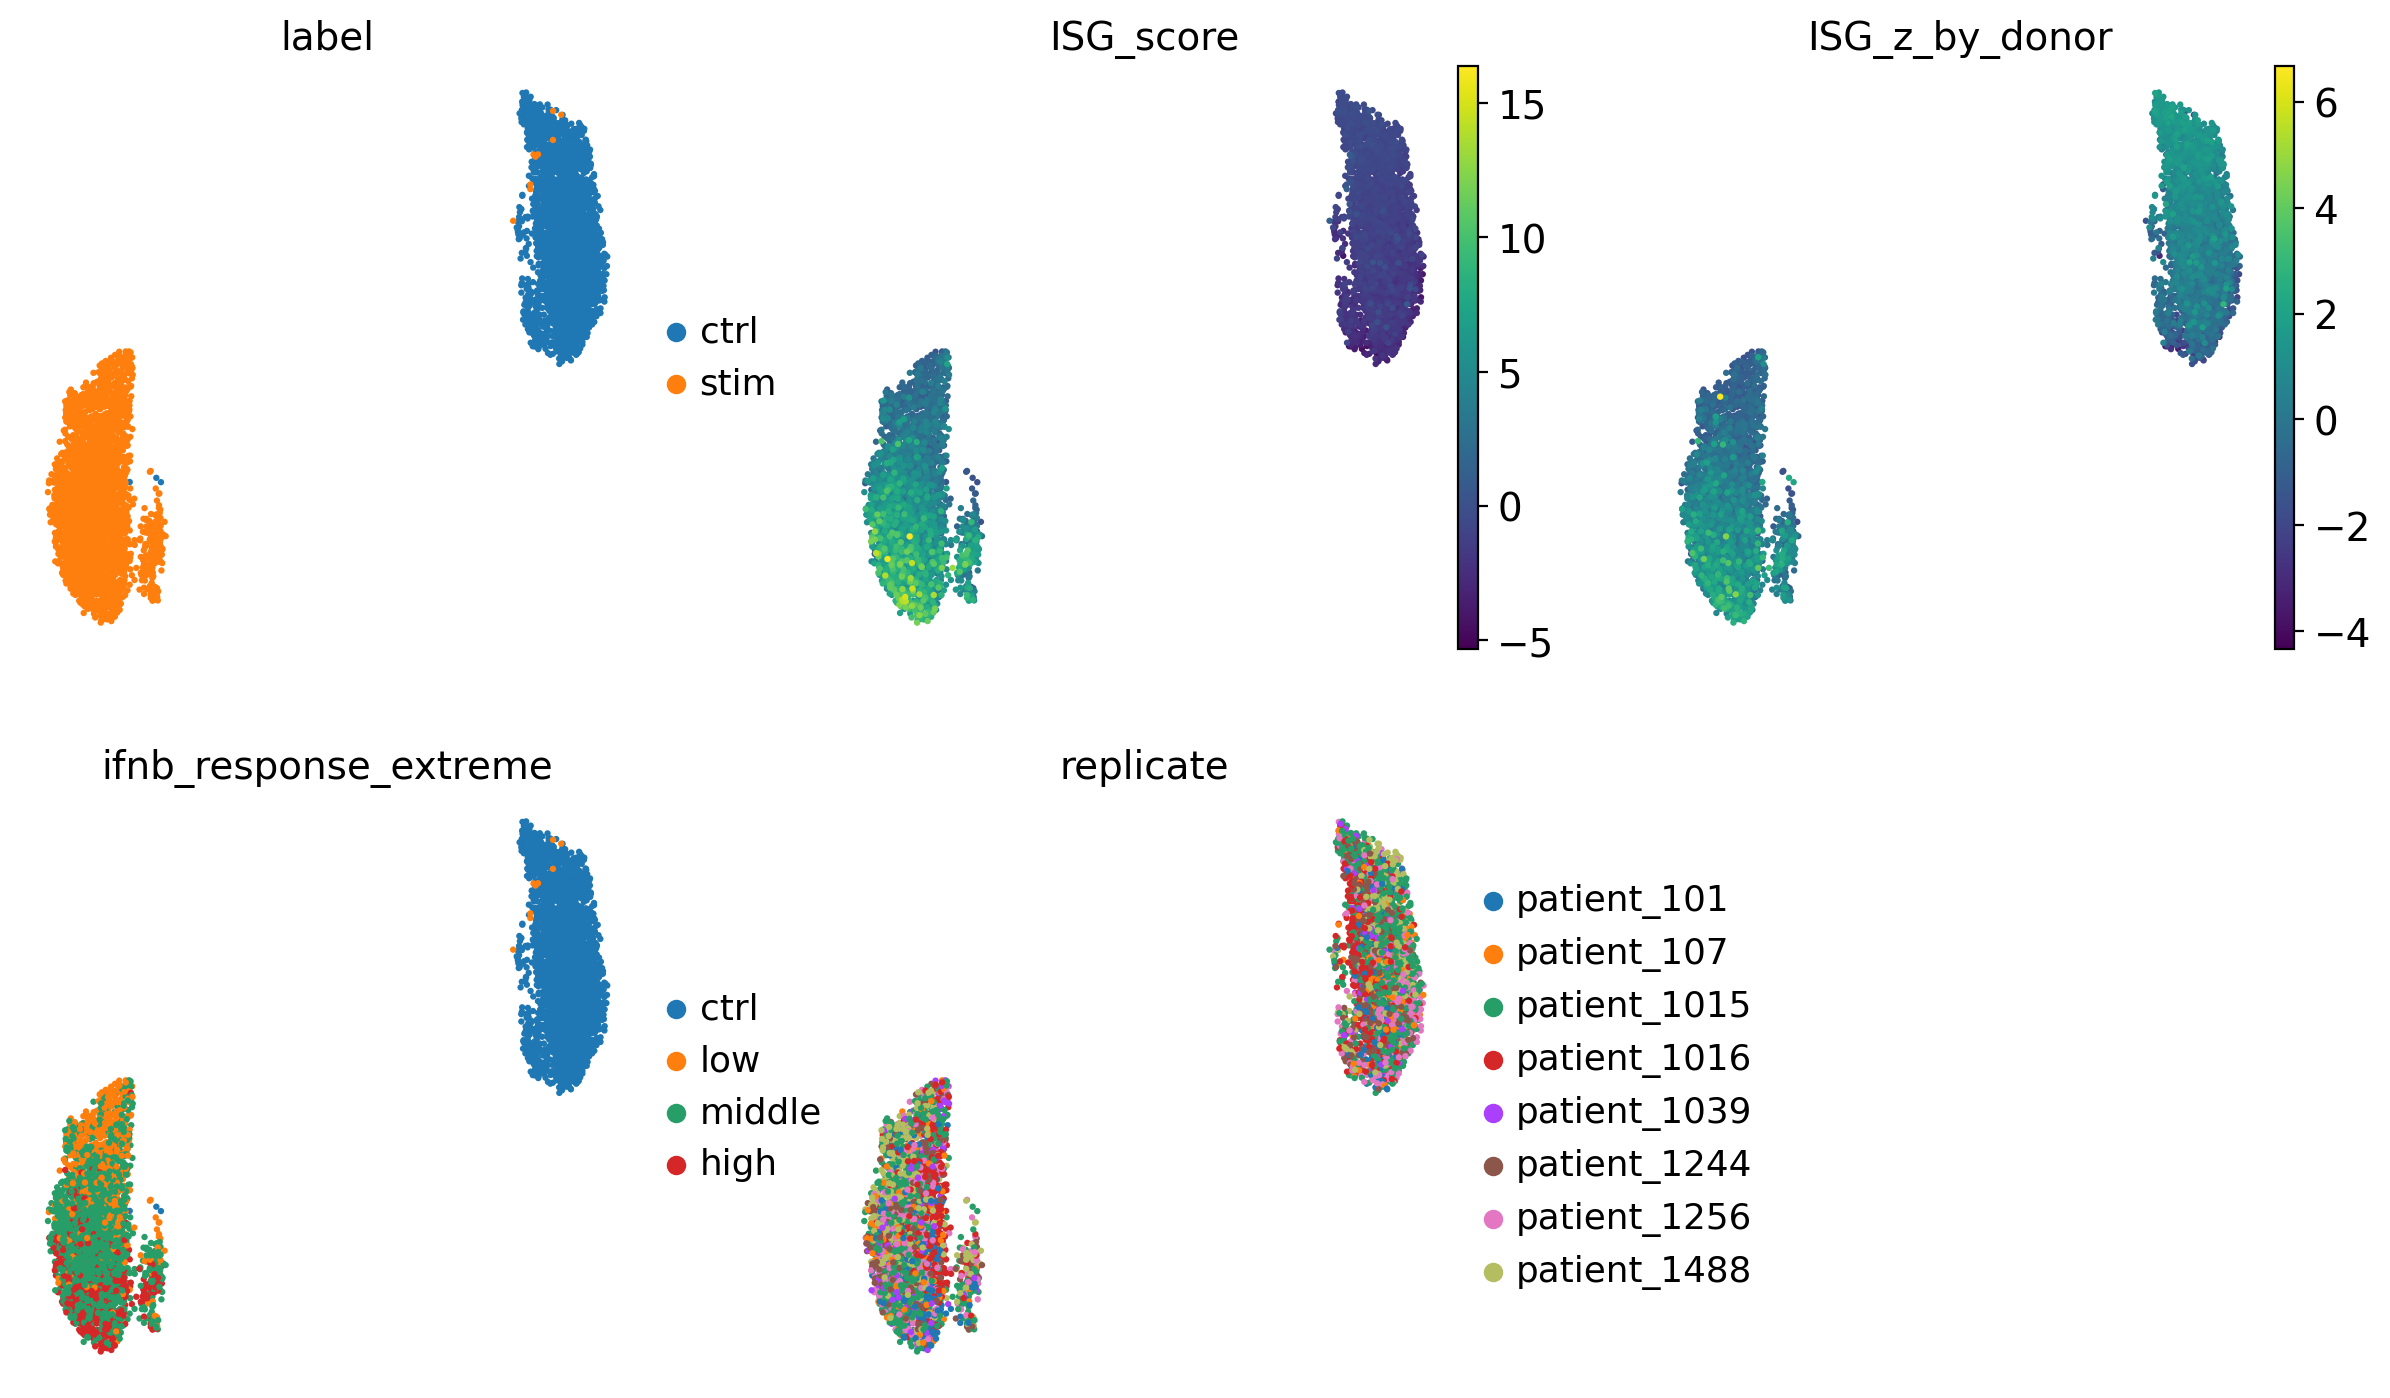

In [6]:
adata_expr = adata_cd14.copy()
sc.pp.normalize_total(adata_expr, target_sum=1e4)
sc.pp.log1p(adata_expr)
sc.pp.scale(adata_expr, max_value=10)
sc.tl.pca(adata_expr, n_comps=min(50, adata_expr.n_vars - 1), svd_solver="arpack")
sc.pp.neighbors(adata_expr, use_rep="X_pca", n_neighbors=30)
sc.tl.umap(adata_expr, min_dist=0.5)

sc.pl.embedding(
    adata_expr,
    basis="X_umap",
    color=["label", "ISG_score", "ISG_z_by_donor", "ifnb_response_extreme", "replicate"],
    ncols=3,
)


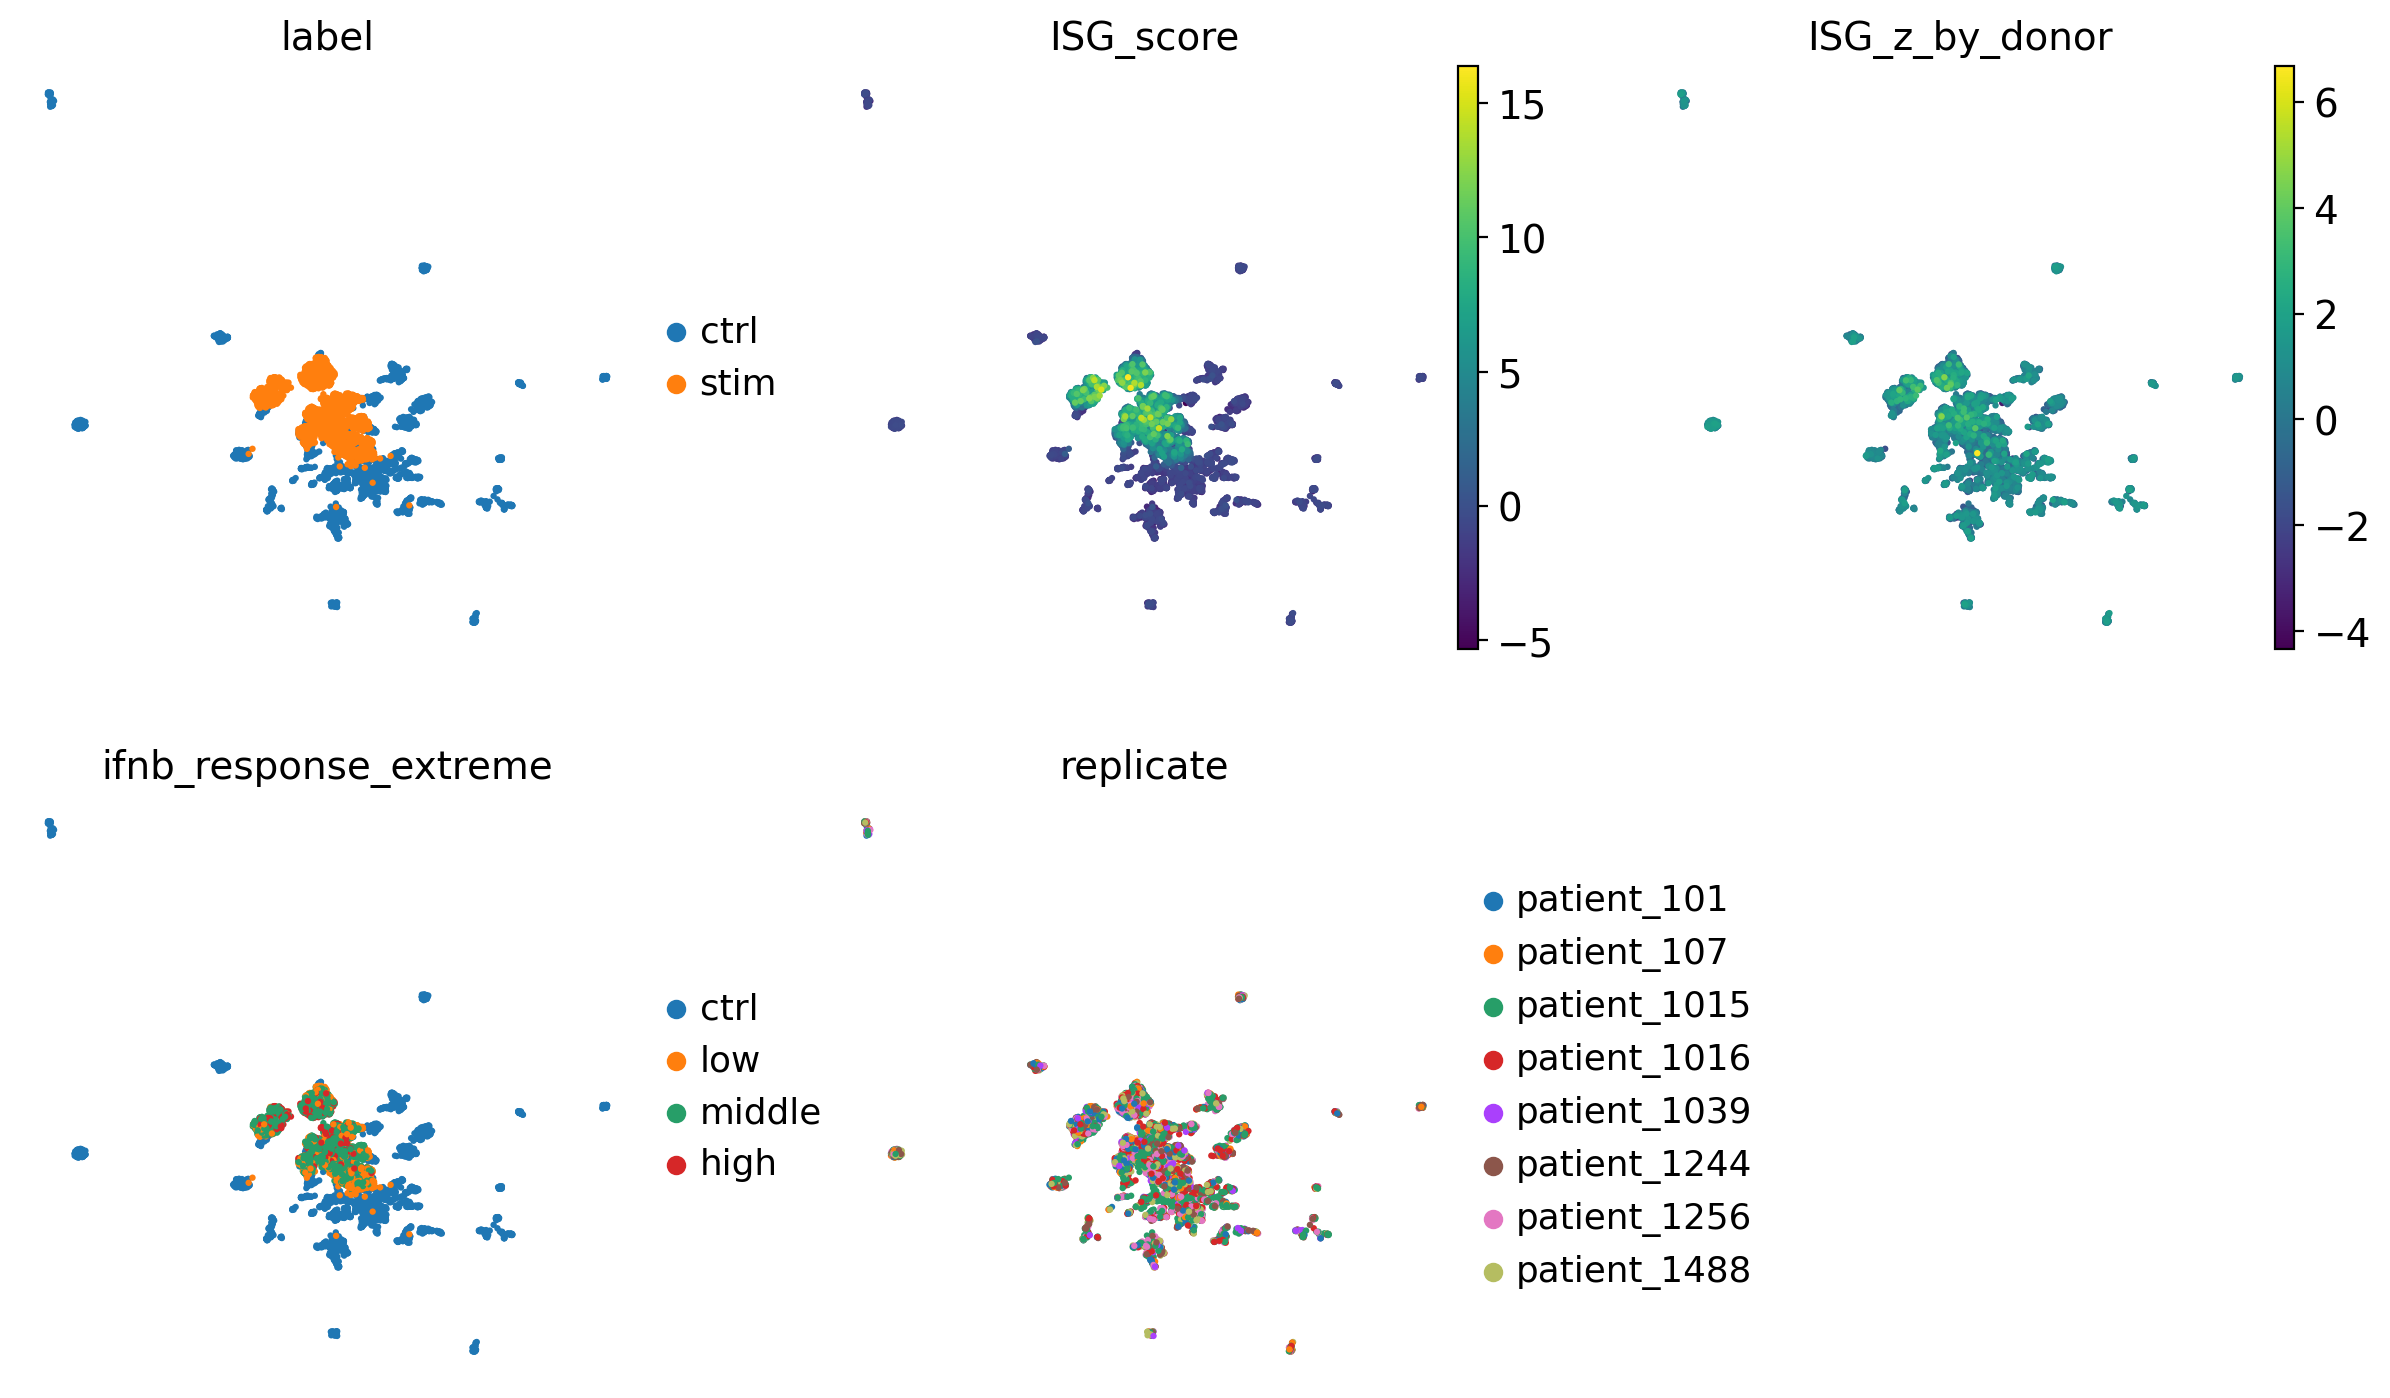

In [7]:
isg_model_genes = present_genes(adata_cd14, IFN_BETA_RESPONSE_GENES)
adata_isg = adata_cd14[:, isg_model_genes].copy()
sc.pp.normalize_total(adata_isg, target_sum=1e4)
sc.pp.log1p(adata_isg)
sc.pp.scale(adata_isg, max_value=10)
sc.tl.pca(adata_isg, n_comps=min(20, adata_isg.n_vars - 1), svd_solver="arpack")
sc.pp.neighbors(adata_isg, use_rep="X_pca", n_neighbors=30)
sc.tl.umap(adata_isg, min_dist=0.5)

sc.pl.embedding(
    adata_isg,
    basis="X_umap",
    color=["label", "ISG_score", "ISG_z_by_donor", "ifnb_response_extreme", "replicate"],
    ncols=3,
)


## Prepare spVIPESmulti inputs

The groups remain `ctrl` and `stim`. The setup registers donor and condition metadata but omits `label_key`, giving an unsupervised CD14-only integration problem.


In [8]:
conditions = ["ctrl", "stim"]
adatas_dict = {}
for condition in conditions:
    sub = adata_cd14[adata_cd14.obs["label"] == condition].copy()
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[condition] = sub
    print(f"{condition}: {sub.shape}")

adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="label",
    sample_key="replicate",
    condition_key="label",
    donor_key="replicate",
)


ctrl: (2932, 7494)
stim: (2765, 7494)
INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          
INFO     spVIPESmulti: Setting up with groups_key: 'label'                                                         
INFO     spVIPESmulti: Samples: Using 'replicate' from adata.obs                                                   
INFO     spVIPESmulti: Conditions: Using 'label' from adata.obs                                                    
INFO     spVIPESmulti: Donors: Using 'replicate' from adata.obs                                                    
INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              
INFO     spVIPESmulti: No labels configured — provide label_key for PoE-based integration                          


In [9]:
N_SHARED = 12
N_PRIVATE = 15
N_HIDDEN = 256
DROPOUT = 0.1
MAX_EPOCHS = 300
BATCH_SIZE = 1024
KL_WARMUP = 150

model = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    disentangle_preset="off",
    disentangle_group_shared_weight=1.0,
    disentangle_group_private_weight=1.0,
    disentangle_donor_shared_weight=0.5,
    disentangle_donor_private_weight=0.0,
    contrastive_weight=0.0,
    use_nf_prior=False,
    use_batch_norm=True,
    use_layer_norm=False,
    dispersion="gene",
)
print(model)


INFO     spVIPESmulti: The model has been initialized                                                              


spVIPESmulti Model with the following params: 
n_hidden: 256, n_dimensions_shared: 12, n_dimensions_private: 15, dropout_rate: 0.1, multimodal: No, nf_prior: No
Training status: Not Trained

In [10]:
group_indices_list = [list(map(int, g)) for g in adata_spv.uns["groups_obs_indices"]]
print("Group sizes:", [len(g) for g in group_indices_list])

model.train(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
    compute_orthogonality_metric=True,
    orthogonality_groupby_keys=("condition", "donor"),
    orthogonality_min_cells_per_stratum=16,
    plan_kwargs={
        "lr_scheduler_type": "cosine",
        "lr_patience": 50,
    },
)


Group sizes: [2932, 2765]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/300 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


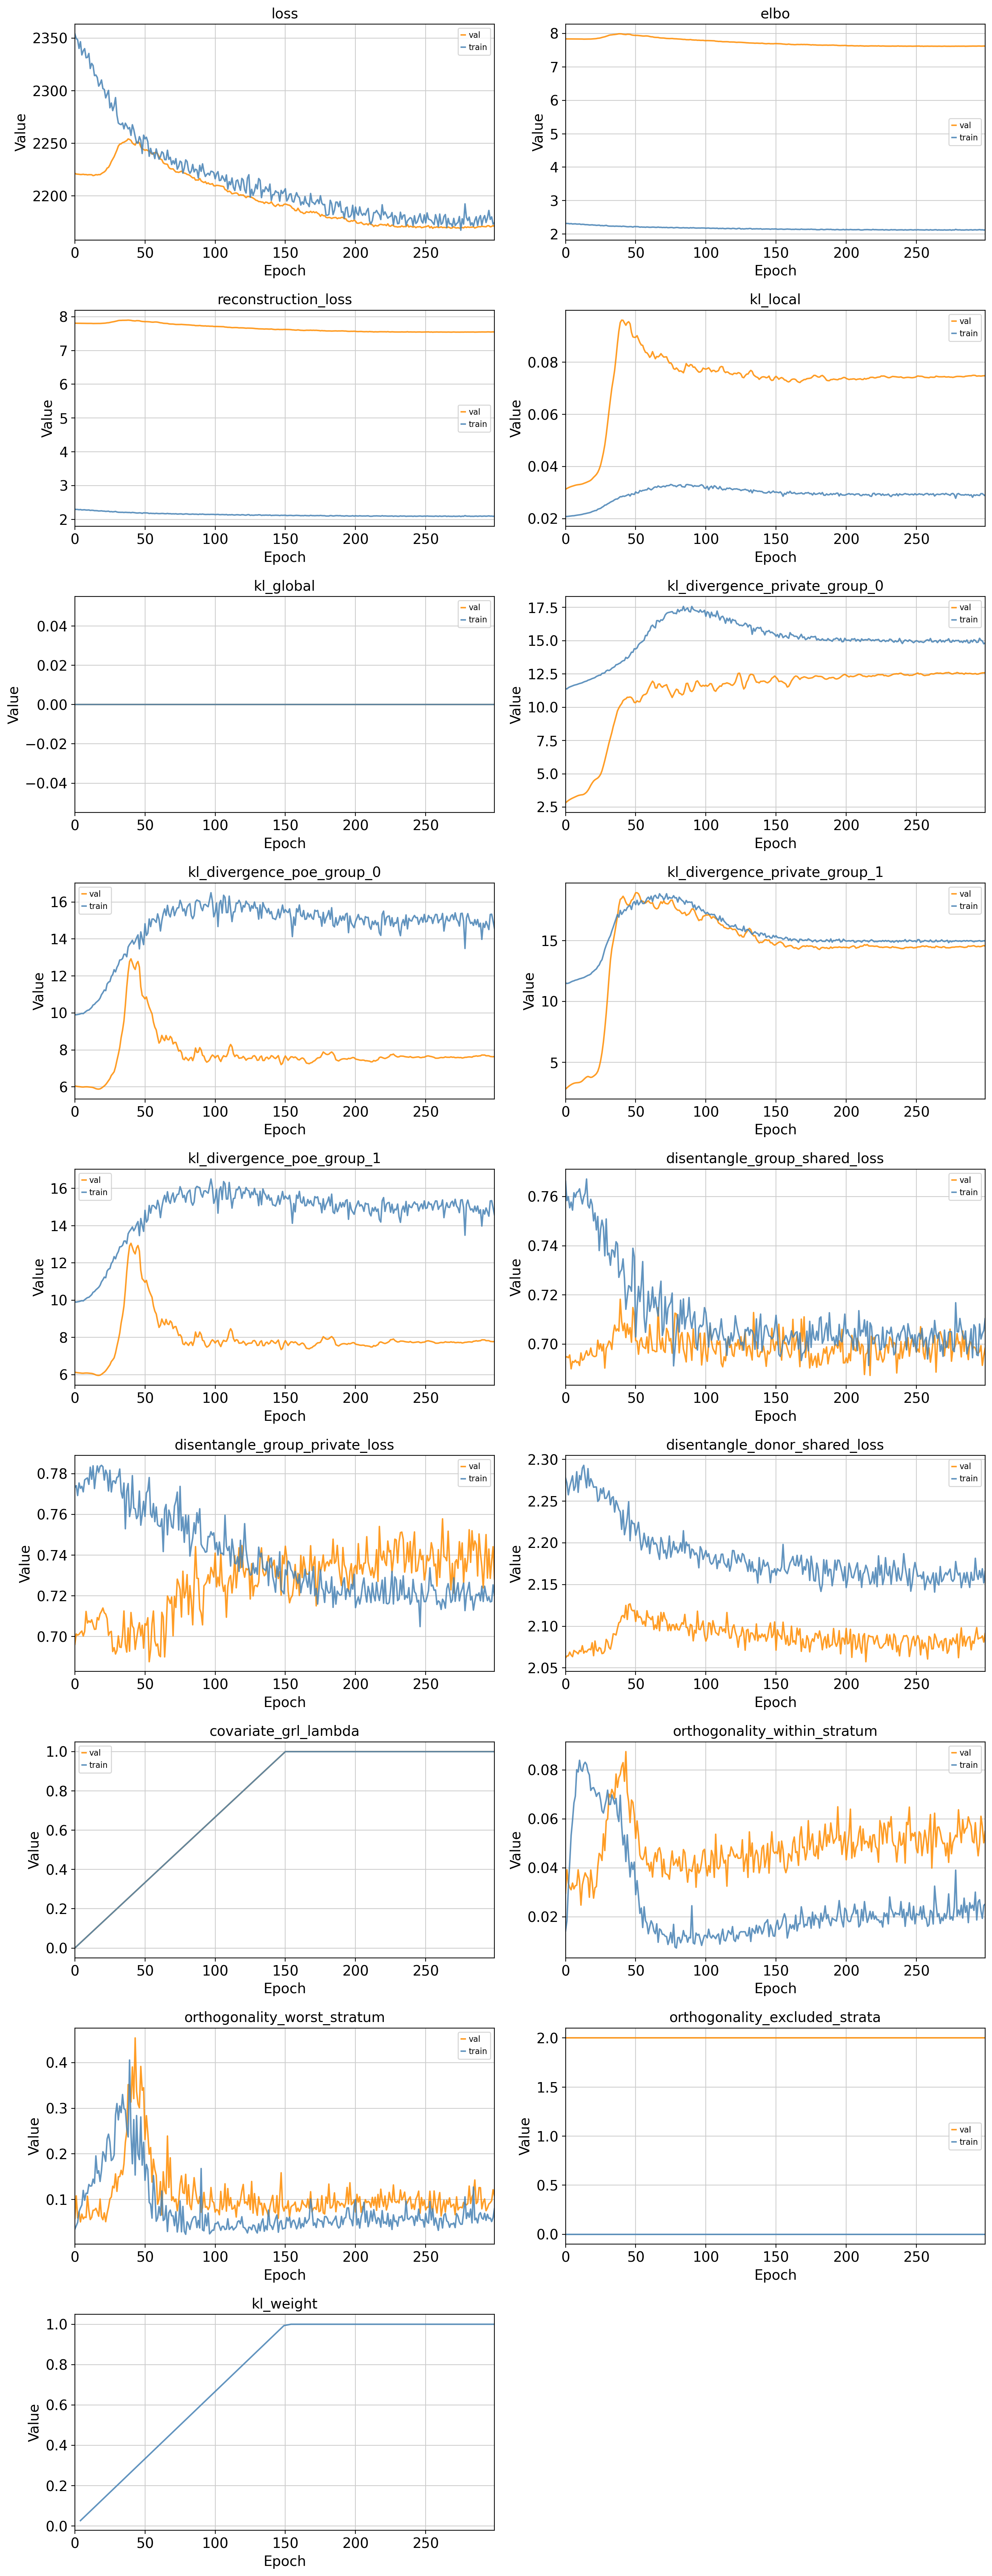

In [11]:
fig = spVIPESmulti.pl.training_curves(model)
plt.show()


## Extract latents and probe what they encode

Condition and donor probes are computed across all CD14 cells. Response probes are computed only within stimulated CD14 cells, and classification excludes the middle response quantile.


In [12]:
latents = model.get_latent_representation(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
)
shared_by_group = latents.get("shared_reordered", latents["shared"])
private_by_group = latents.get("private_reordered", latents["private"])

n_shared_fit = shared_by_group[0].shape[1]
n_private_fit = private_by_group[0].shape[1]
latent_shared = np.zeros((adata_spv.n_obs, n_shared_fit), dtype=np.float32)
latent_private = np.zeros((adata_spv.n_obs, n_private_fit), dtype=np.float32)
for group_idx, obs_idx in enumerate(group_indices_list):
    latent_shared[np.asarray(obs_idx)] = shared_by_group[group_idx]
    latent_private[np.asarray(obs_idx)] = private_by_group[group_idx]

adata_spv.obsm["X_spVIPES_shared"] = latent_shared
adata_spv.obsm["X_spVIPES_private"] = latent_private

adatas_ctrl = adatas_dict["ctrl"].copy()
adatas_stim = adatas_dict["stim"].copy()
adatas_ctrl.obsm["X_spVIPES_private"] = private_by_group[conditions.index("ctrl")]
adatas_stim.obsm["X_spVIPES_private"] = private_by_group[conditions.index("stim")]

stim_mask_spv = adata_spv.obs["label"].astype(str).to_numpy() == "stim"
adata_spv_stim = adata_spv[stim_mask_spv].copy()
adata_spv_stim_extreme = adata_spv_stim[adata_spv_stim.obs["ifnb_response_extreme"].isin(["low", "high"])].copy()
adatas_stim_extreme = adatas_stim[adatas_stim.obs["ifnb_response_extreme"].isin(["low", "high"])].copy()

print("shared:", latent_shared.shape, "private:", latent_private.shape)
print("stim response extremes:", adatas_stim_extreme.obs["ifnb_response_extreme"].value_counts().to_dict())


shared: (5697, 12) private: (5697, 15)
stim response extremes: {'low': 555, 'high': 555}


In [13]:
probe_rows = []
for latent_name, x in {"shared": latent_shared, "private": latent_private}.items():
    for target_name, obs_key in {
        "condition": "label",
        "donor": "replicate",
    }.items():
        probe_rows.append({
            "latent": latent_name,
            "target": target_name,
            "scope": "all_cd14",
            "balanced_accuracy": probe_balanced_accuracy(x, adata_spv.obs[obs_key]),
        })

response_probe_inputs = {
    "shared": np.asarray(adata_spv_stim_extreme.obsm["X_spVIPES_shared"]),
    "private": np.asarray(adatas_stim_extreme.obsm["X_spVIPES_private"]),
}
for latent_name, x in response_probe_inputs.items():
    probe_rows.append({
        "latent": latent_name,
        "target": "response_low_vs_high",
        "scope": "stim_cd14_extremes",
        "balanced_accuracy": probe_balanced_accuracy(x, adatas_stim_extreme.obs["ifnb_response_extreme"]),
    })

probe_df = pd.DataFrame(probe_rows)
probe_df.pivot(index=["scope", "target"], columns="latent", values="balanced_accuracy")


latent                                    private    shared
scope              target                                  
all_cd14           condition             0.604409  0.504333
                   donor                 0.146999  0.140809
stim_cd14_extremes response_low_vs_high  0.903813  0.762824

In [14]:
private_response = latent_response_summary(adatas_stim, "X_spVIPES_private")
shared_response = latent_response_summary(adata_spv_stim, "X_spVIPES_shared")

print("Top stimulated private dimensions by donor-adjusted IFN response:")
print(private_response.head(10).to_string(index=False))

print("\nTop stimulated shared dimensions by donor-adjusted IFN response:")
print(shared_response.head(10).to_string(index=False))


Top stimulated private dimensions by donor-adjusted IFN response:
 dim  n_cells  n_low  n_high  spearman_r  spearman_abs    spearman_p  auc_high_vs_low  auc_directionless  spearman_p_adj_bh
   5     2765    555     555    0.571364      0.571364 2.044204e-239         0.901674           0.901674      3.066306e-238
  14     2765    555     555   -0.564942      0.564942 6.040524e-233         0.101638           0.898362      4.530393e-232
   4     2765    555     555    0.562626      0.562626 1.201837e-230         0.902699           0.902699      6.009185e-230
   9     2765    555     555    0.559475      0.559475 1.506759e-227         0.905417           0.905417      5.650347e-227
   0     2765    555     555   -0.557414      0.557414 1.538163e-225         0.102751           0.897249      4.614490e-225
  12     2765    555     555   -0.554797      0.554797 5.210765e-223         0.106245           0.893755      1.302691e-222
   7     2765    555     555   -0.553790      0.553790 4.841909e-2

In [15]:
best_private = private_response.iloc[0]
abs_r = float(best_private["spearman_abs"])
best_auc = float(best_private["auc_directionless"])
if abs_r >= 0.30 or best_auc >= 0.75:
    response_strength = "moderate"
elif abs_r >= 0.15 or best_auc >= 0.65:
    response_strength = "weak-to-moderate"
elif abs_r >= 0.08 or best_auc >= 0.58:
    response_strength = "weak"
else:
    response_strength = "minimal"

print(
    f"Corrected interpretation: the strongest private dimension shows a {response_strength} "
    f"donor-adjusted IFN-response gradient (dim {int(best_private['dim'])}, "
    f"|rho|={abs_r:.3f}, directionless AUC={best_auc:.3f})."
)
print("Do not interpret this as evidence for a discrete unsupervised IFNb-responsive cluster unless the UMAPs also show separation.")


Corrected interpretation: the strongest private dimension shows a moderate donor-adjusted IFN-response gradient (dim 5, |rho|=0.571, directionless AUC=0.902).
Do not interpret this as evidence for a discrete unsupervised IFNb-responsive cluster unless the UMAPs also show separation.


## Visualize the response gradient

These plots show whether the strongest response-associated private dimensions create a gradient, a donor split, or a true discrete separation.


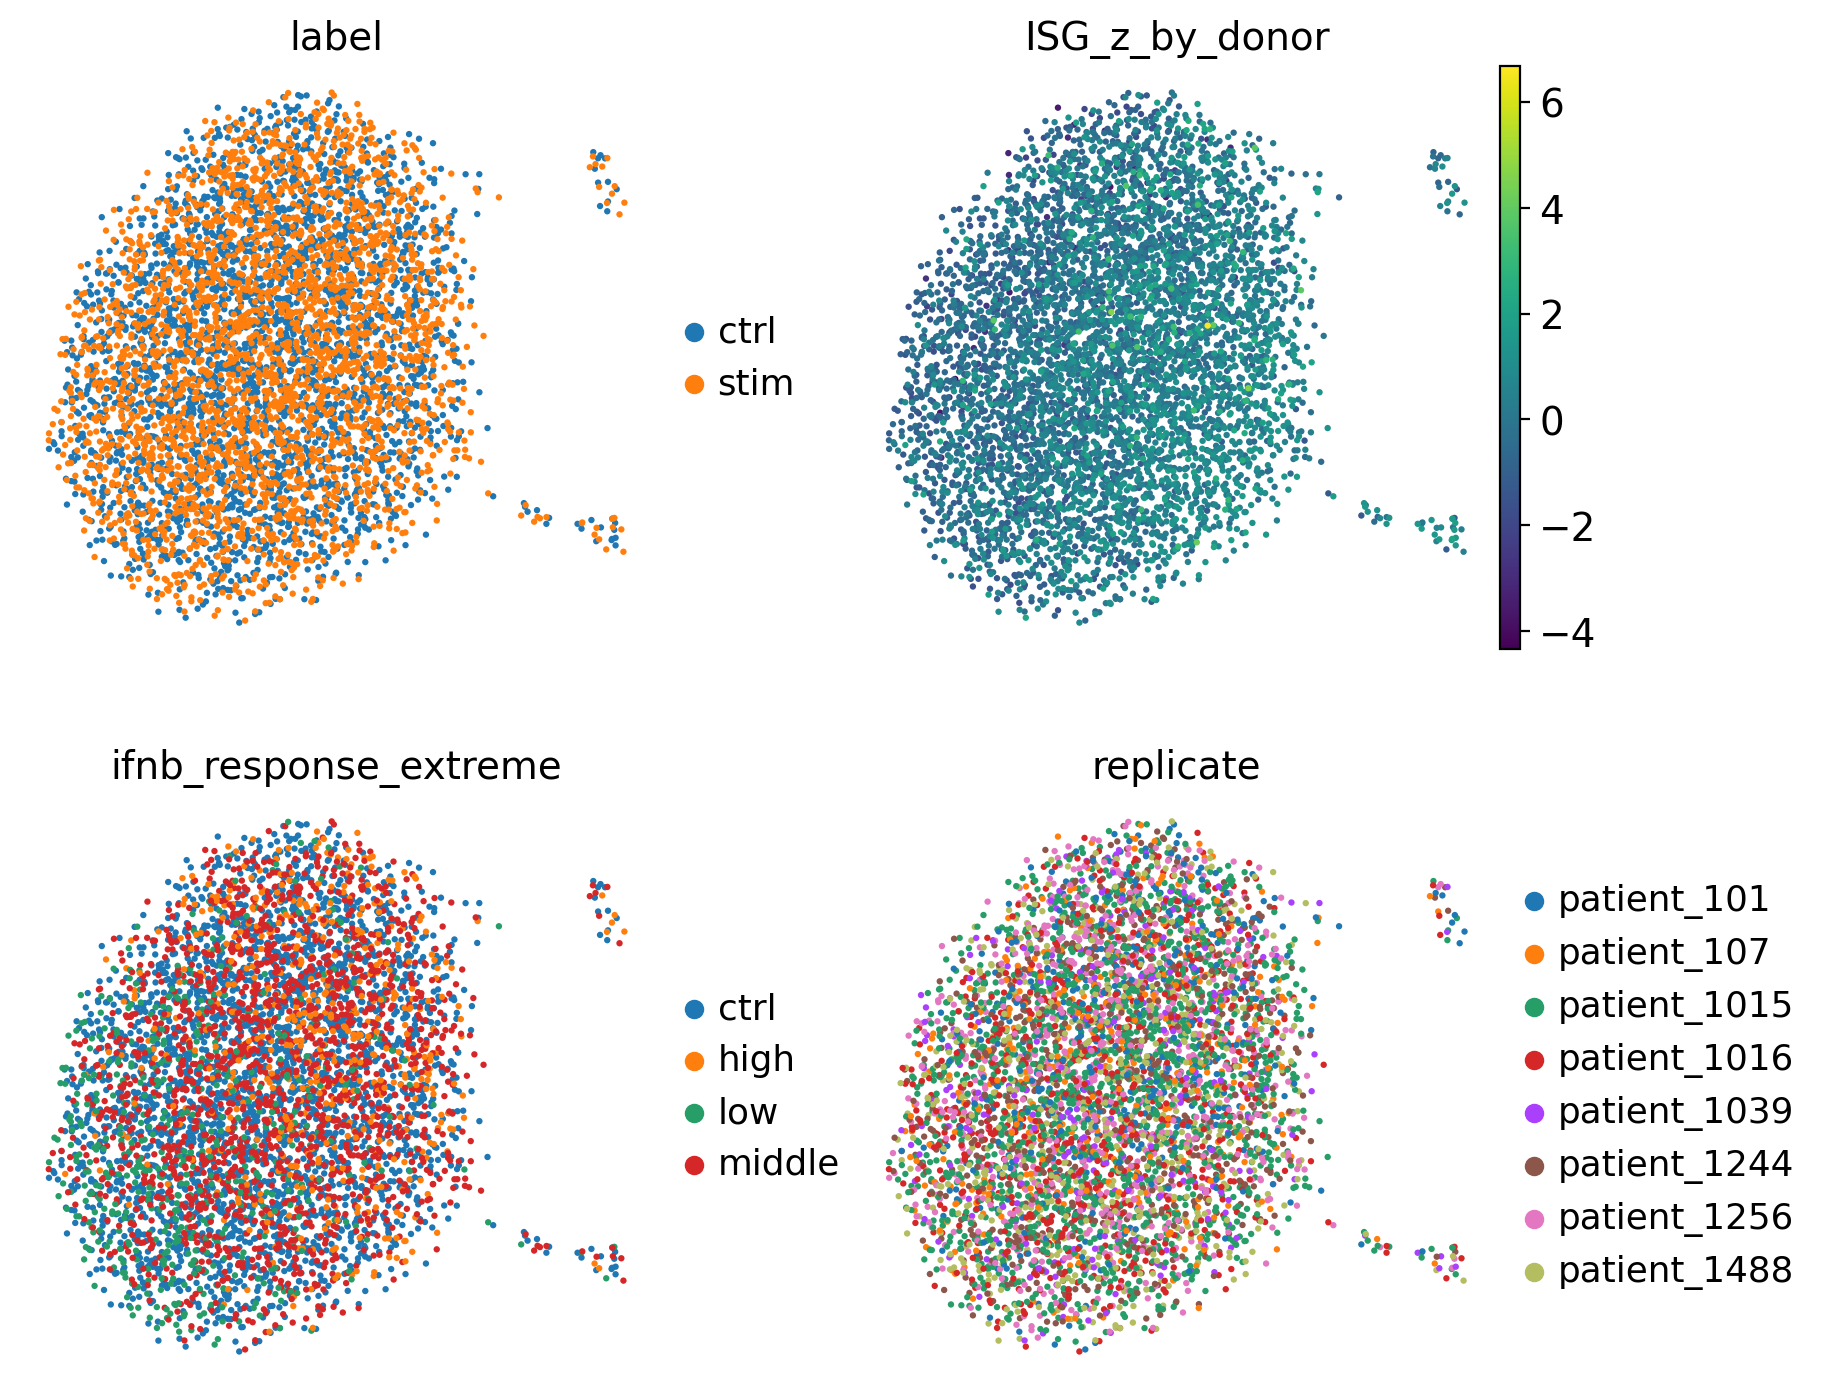

In [16]:
sc.pp.neighbors(adata_spv, use_rep="X_spVIPES_shared", n_neighbors=15)
sc.tl.umap(adata_spv, min_dist=1)
sc.pl.embedding(
    adata_spv,
    basis="X_umap",
    color=["label", "ISG_z_by_donor", "ifnb_response_extreme", "replicate"],
    ncols=2,
)


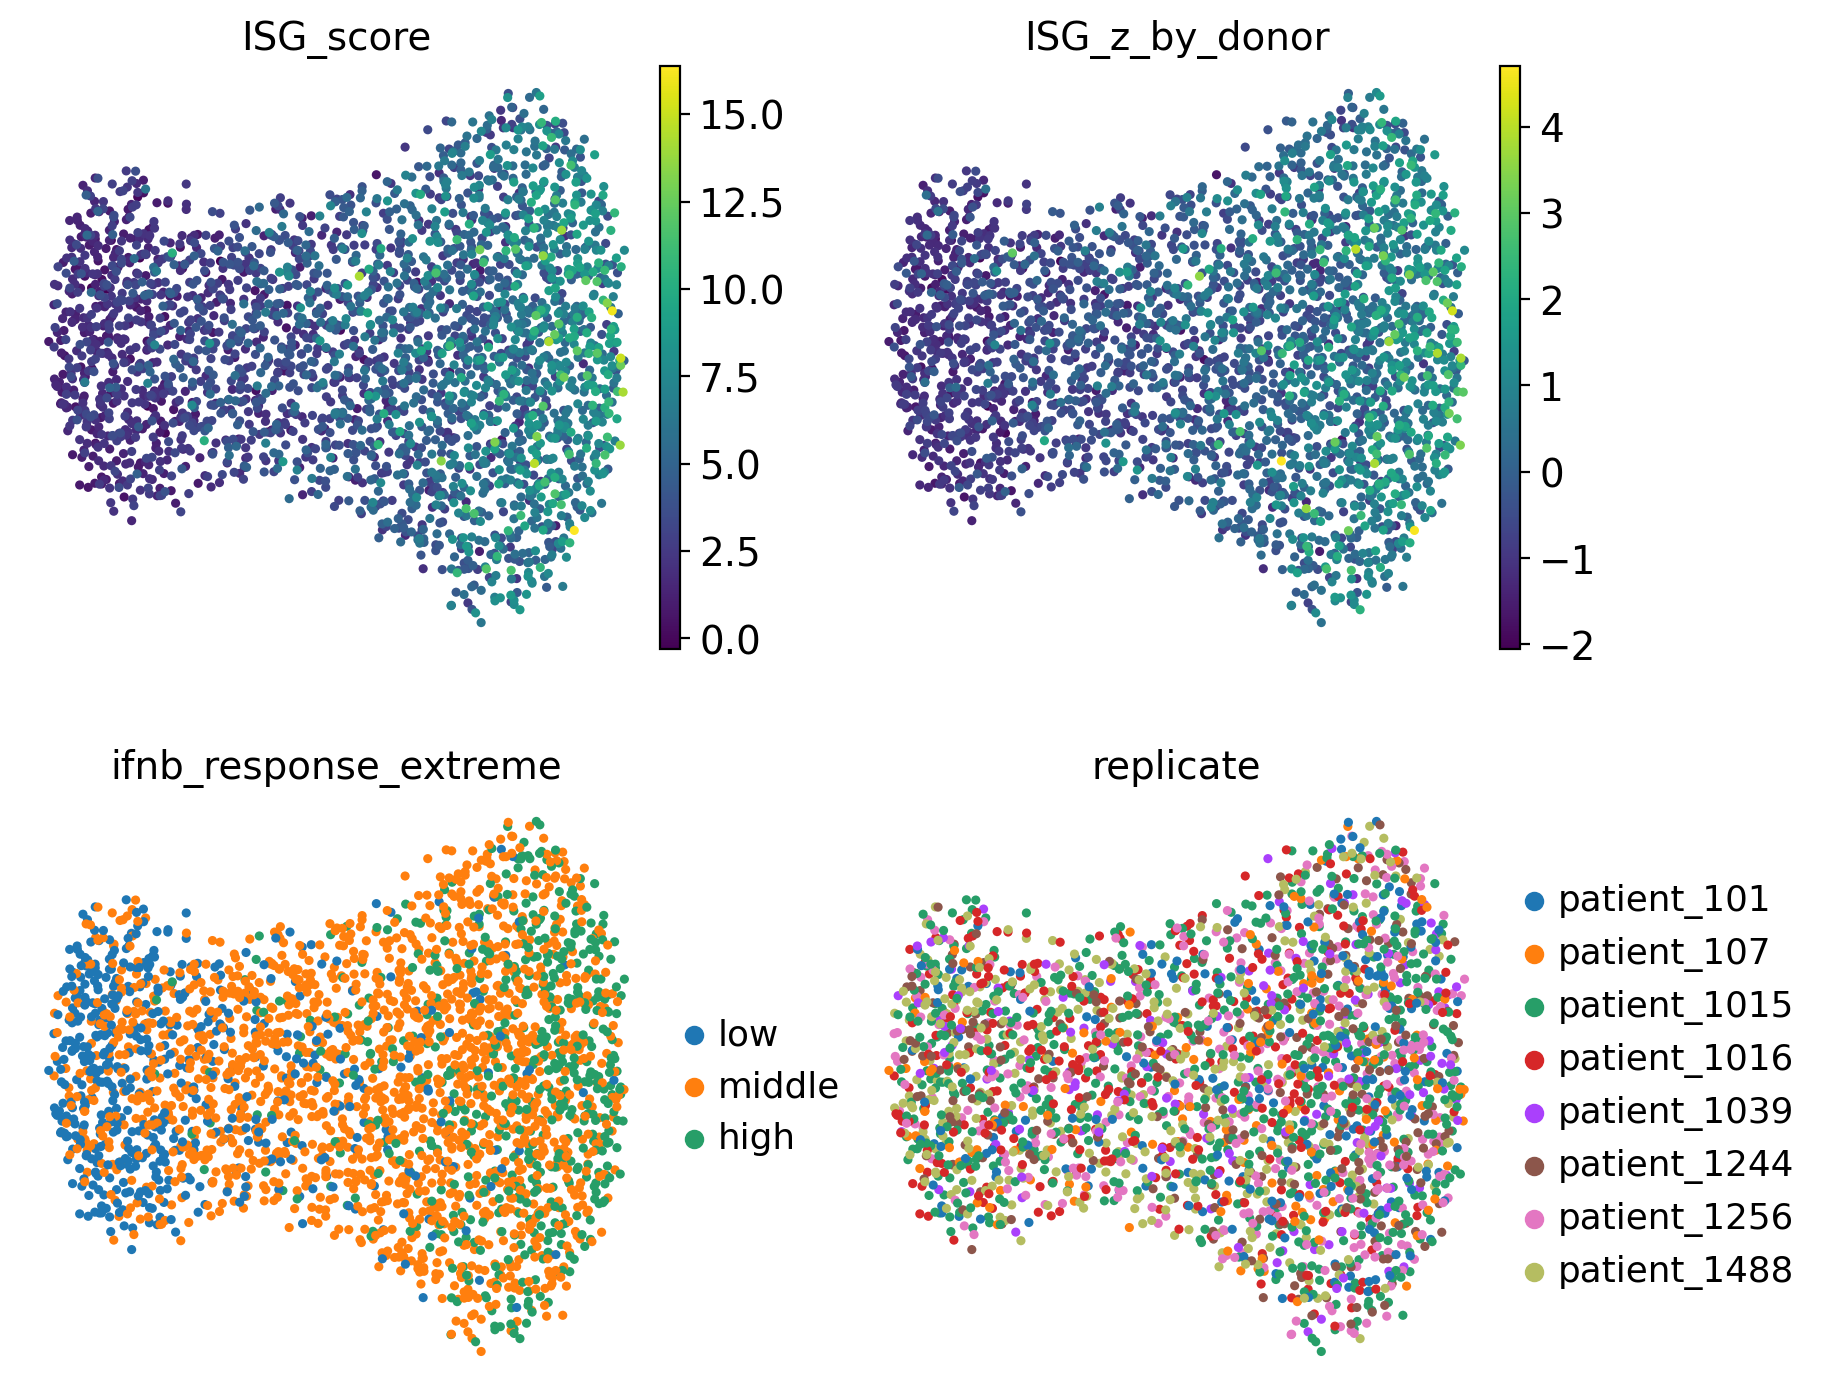

In [17]:
sc.pp.neighbors(adatas_stim, use_rep="X_spVIPES_private", key_added="spvipes_private", n_neighbors=30)
sc.tl.umap(adatas_stim, neighbors_key="spvipes_private", min_dist=0.5)

sc.pl.embedding(
    adatas_stim,
    basis="X_umap",
    color=["ISG_score", "ISG_z_by_donor", "ifnb_response_extreme", "replicate"],
    ncols=2,
)


Top private response dimensions: [5, 14, 4, 9, 0, 12]


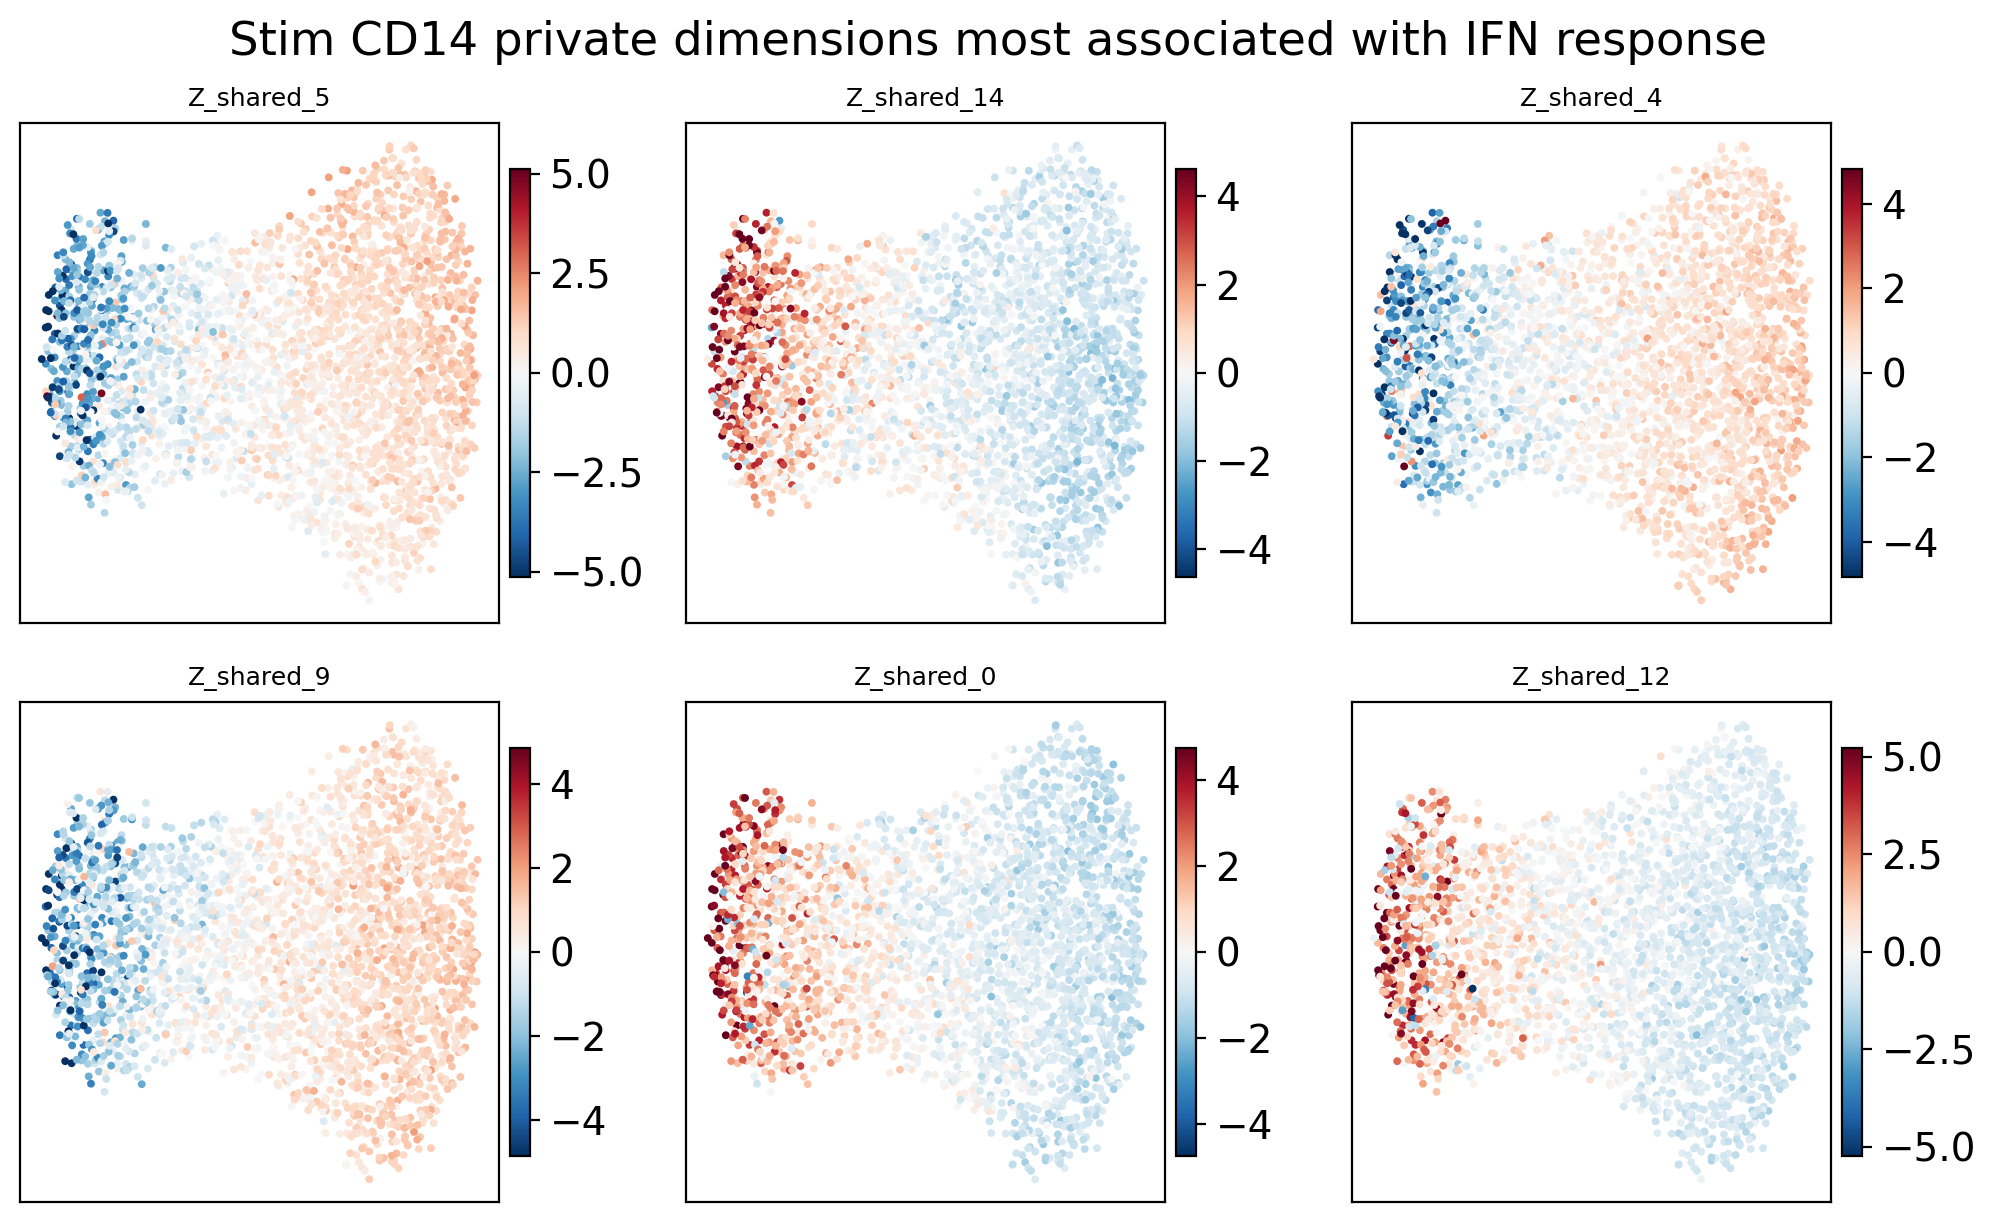

In [18]:
top_private_dims = private_response.head(6)["dim"].astype(int).tolist()
print("Top private response dimensions:", top_private_dims)

fig = spVIPESmulti.pl.plot_latent_dims_in_umap(
    adatas_stim,
    obsm_key="X_spVIPES_private",
    dims=top_private_dims,
    ncols=3,
    figsize_per_panel=(3.4, 3.0),
)
fig.suptitle("Stim CD14 private dimensions most associated with IFN response", y=1.02)
fig.show()


In [19]:
for dim_idx in top_private_dims:
    adatas_stim.obs[f"private_{dim_idx}"] = adatas_stim.obsm["X_spVIPES_private"][:, dim_idx]

sc.pl.violin(
    adatas_stim_extreme,
    keys=[f"private_{dim_idx}" for dim_idx in top_private_dims],
    groupby="ifnb_response_extreme",
    rotation=45,
    multi_panel=True,
)


KeyError: "Could not find keys ['private_5', 'private_14', 'private_4', 'private_9', 'private_0', 'private_12'] in columns of `adata.obs` or in adata.var_names."

## Interpret response-associated factors

Loadings are inspected only after identifying response-associated dimensions. This avoids interpreting dimensions that mostly encode condition, donor, or residual technical variation.


In [ ]:
top_stim = spVIPESmulti.utils.get_top_genes(
    model=model,
    group_idx=conditions.index("stim"),
    latent_type="private",
    n_top=50,
    signed=True,
)

top_dim_names = [f"Z_private_{dim_idx}" for dim_idx in top_private_dims]
response_loading_table = top_stim[top_stim["dim"].isin(top_dim_names)].copy()
loading_csv = NOTEBOOK_DIR / "kang_ifn_cd14_private_response_loadings.csv"
response_loading_table.to_csv(loading_csv, index=False)
print(f"Wrote {loading_csv}")
response_loading_table[["dim", "pos_genes", "neg_genes"]]


In [ ]:
ax = private_loadings_heatmap(
    model=model,
    group_idx=conditions.index("stim"),
    dims=top_private_dims,
    n_top=8,
)
plt.show()


## Optional comparison: global threshold

This final plot keeps the old `ISG_score > 5` threshold as a diagnostic only. The corrected donor-adjusted CD14 low/high labels above are the response definition used for the model probes.


In [ ]:
adatas_stim.obs["ifnb_responsive_global5"] = adatas_stim.obs["ISG_score"] > 5
adatas_stim.obs["ifnb_responsive_global5"] = adatas_stim.obs["ifnb_responsive_global5"].astype("category")

sc.pl.embedding(
    adatas_stim,
    basis="X_umap",
    color=["ISG_score", "ISG_z_by_donor", "ifnb_responsive_global5", "ifnb_response_extreme"],
    ncols=2,
)
